# Walt TS-DMIM: Quickstart Tutorial
This notebook demonstrates how to load data, run the `TemporalAnalyzer`, and extract topological causality profiles using the Delta Moment-Independent Measure (DMIM).

**Note:** Our target variable (`T`) contains a duplicate reading at timestep 50. The library natively handles this without artificially averaging the physical variance.

In [1]:
import pandas as pd
from walt_ts_dmim import TemporalAnalyzer
from walt_ts_dmim.diagnostics import plot_diagnostic_grid

# 1. Load the synthetic datasets
weather_df = pd.read_csv("synthetic_weather.csv")
indoor_df = pd.read_csv("synthetic_indoor.csv")

# 2. Prepare the 1D continuous weather timeline
weather_df.set_index("timestep", inplace=True)

print(f"Weather Timeline: {len(weather_df)} continuous steps")
print(f"Indoor Measurements: {len(indoor_df)} (Includes duplicate at step 50)")

Weather Timeline: 100 continuous steps
Indoor Measurements: 101 (Includes duplicate at step 50)


### 2. Initialize and Run the Analyzer
We sweep up to 24 time-steps into the past to build our sensitivity curves.

In [2]:
# ==========================================
# 2. Initialize and Run the Analyzer
# ==========================================
analyzer = TemporalAnalyzer(
    weather_df=weather_df,  # The input df
    indoor_df=indoor_df,    # The output df (indoor temperature)
    target_col="T",         # The output feature
    max_lag_steps=24        # The number of time-steps preceding the output parameter that we want to do temporal sensitivity analysis on
)

# Run the DMIM Sweeps using parallel processing
# n_jobs=-2 automatically uses all available CPU cores MINUS ONE, leaving your PC responsive
dmim_curves = analyzer.compute_sweeps(num_resamples=10, seed=42, n_jobs=-2)

# Extract Topological Profiles (Causal Basin Isolation)
profiles = analyzer.generate_profiles(smooth_window=3)

# Compute baseline Auto-Correlation for the visuals
acf_curves = analyzer.compute_acf()

# Optional: Export all raw statistics and metrics to disk for mass-rollout tracking
analyzer.export_results(output_dir="examples/results/", file_prefix="tutorial_synthetic")

print("✅ Pipeline Complete. Data exported to examples/results/")

# ==========================================
# 3. Visual Diagnostics
# ==========================================
%matplotlib inline
from walt_ts_dmim.diagnostics import plot_diagnostic_grid

# Render the plots dynamically and save a high-res PNG to disk
plot_diagnostic_grid(
    dmim_curves_dict=dmim_curves, 
    acf_curves_dict=acf_curves, 
    profiles_dict=profiles,
    smooth_window=3,
    title_prefix="[SYNTHETIC TEST]",
    save_path="examples/results/tutorial_synthetic_plot.png"
)

2026-06-18 11:30:54,807 - INFO - TemporalAnalyzer initialized. Max lag: 24 steps.
2026-06-18 11:30:58,314 - INFO - Computing continuous ACF baseline...


✅ DMIM Sweeps and Topological Profiles Generated.


### 3. Visual Diagnostics
Plot the topological extraction alongside the raw DMIM sensitivity and baseline ACF.


[!] Plot successfully saved to diagnostic_grid_results.png


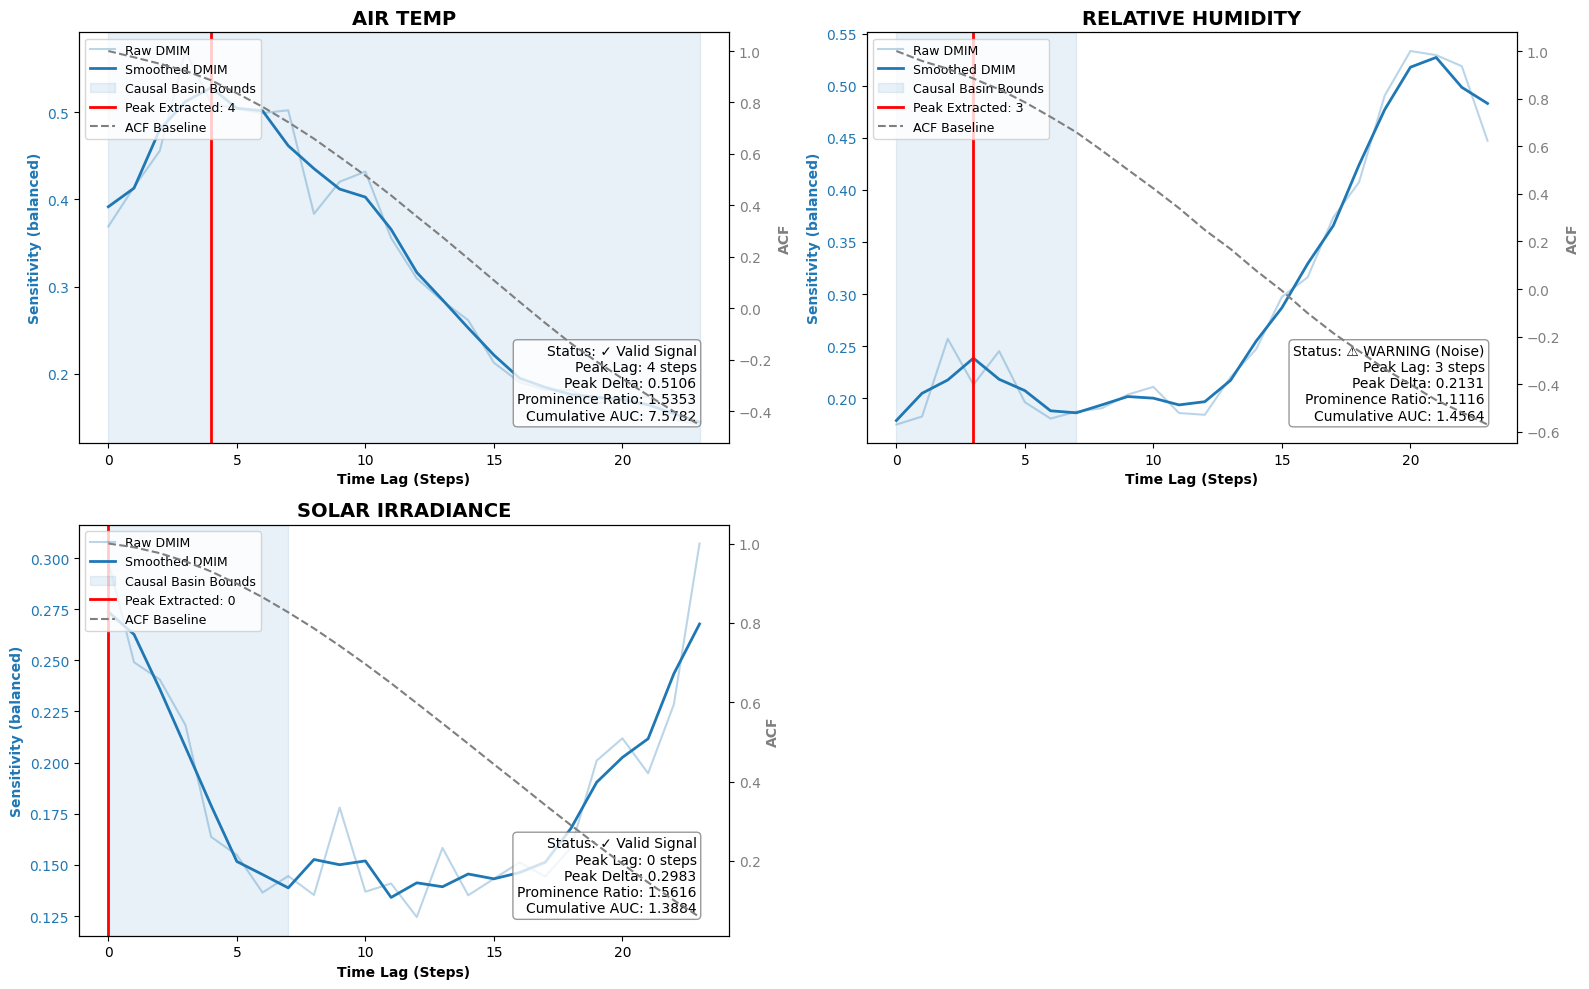

In [3]:
%matplotlib inline

plot_diagnostic_grid(
    dmim_curves_dict=dmim_curves, 
    acf_curves_dict=acf_curves, 
    profiles_dict=profiles,  # <-- Pass the objects directly!
    smooth_window=3,
    show_plot=True
)

### 4. Decoding Your Diagnostic Profiles & Optimizing Runs

The Walt-TS-DMIM framework translates raw temporal statistical sensitivity into dynamic physical behavior. To read these plots correctly, keep the context of our tutorial experiment in mind:
* **Inputs (Weather):** Air Temperature, Relative Humidity, Solar Irradiance.
* **Target Output ($T$):** Indoor Temperature.
* **Resolution:** 1 step (e.g., 5-minute logging intervals).

Here is how to decode the visual topography, metrics, and automation parameters generated by the framework.

#### Part 1: The Visual Topography

* **The Physical Time Translation (The X-Axis):**
  The engine operates on pure index steps to maximize computational speed. To find your true physical lag, multiply the **Peak Lag** by your dataset's original logging interval. 
  > *Example:* In the **Air Temp** plot, the peak is extracted at **4 steps**. If your sensors logged data every 5 minutes, the true physical delay before outside air temperature maximally impacts your indoor space is exactly 20 minutes. 

* **The ACF Baseline (The Gray Dashed Line):**
  Weather variables are inherently "sticky" (e.g., the temperature right now is highly correlated with the temperature 5 minutes ago). This is the Autocorrelation Function (ACF). 
  > *The Scientific Utility:* Standard sensitivity tools often flag false time-lags simply because the weather itself hasn't changed. By plotting the non-linear DMIM sensitivity curve (blue) against the linear ACF baseline (gray), you can visually verify if the thermodynamic influence is a genuine building reaction, or just a statistical ghost of the weather's own autocorrelation.

* **The Causal Basin (The Blue Shaded Region):**
  This represents the absolute boundaries of the thermodynamic event, extracted by finding the localized mathematical valleys on either side of the causal peak.
  > *The Practical Utility:* Think of the Causal Basin as the **"Window of Influence."** It tells you exactly when the weather variable begins to measurably affect the room, and exactly when its influence dissipates back into the baseline noise floor.

#### Part 2: Deciphering the Causal Metrics

Inside the diagnostic box on each plot, the engine computes heuristics designed to filter out sensor jitter and false positives:

* **Status Flag (✅ or ⚠️):**
  An immediate visual grade of the signal's validity, driven by the Prominence Ratio. 

* **Peak Delta ($\delta$):** The absolute magnitude of sensitivity at the peak time step. Higher values indicate that the variable dictates a larger percentage of the target variable's distribution variance at that specific moment.

* **Prominence Ratio (The Confidence Score):** The signal-to-noise ratio of the peak relative to its surrounding basin. The framework uses an empirical threshold of $\approx 1.15$ to separate true physical causality from background variance.
  > * **Solar Irradiance:** Shows a strong prominence of **1.56**. This is a highly confident, distinct physical signal.
  > * **Relative Humidity:** Shows a prominence of **1.11**. Because this falls below the threshold, the framework warns you (`⚠️ WARNING (Noise)`) that this peak is practically indistinguishable from the background statistical noise. It is likely a false positive.

* **Duration ($t > 0.98$):** The "Peak Plateau." This measures how many consecutive time steps the sensitivity remains at or above 98% of its absolute maximum. A wider duration suggests a slow, sustained transfer of energy, while a duration of 1 indicates a sharp, transient spike.

* **Cumulative AUC (Area Under Curve):** The integral of the sensitivity curve across the entire Causal Basin. While *Peak Delta* isolates the maximum instantaneous impact, *Cumulative AUC* quantifies the total sustained impact of that variable over the entire thermodynamic event.

#### Part 3: Scaling & Automation (Mass Rollout)
For researchers running hundreds of datasets or analyzing long-term historical data, the library includes built-in parallelization and export controls:

* **Core Parallelization (`n_jobs`):** In `compute_sweeps()`, you can distribute the massive Kernel Density Estimation (KDE) math across multiple CPU cores. 
    * Set `n_jobs=4` to strictly limit the run to 4 cores. 
    * Set `n_jobs=-2` to automatically use **all cores minus one**. This maximizes computation speed while leaving one core free so your computer's operating system remains responsive. The engine natively manages thread-limiting under the hood to prevent server oversubscription/crashing.
* **Batch Exporting (`export_results`):** Instead of manually saving outputs, this command dumps the topological metrics, raw DMIM arrays, and ACF baselines into standardized CSVs for cross-dataset statistical comparison.
* **Dynamic Plotting (`title_prefix` & `save_path`):** Inject dataset-specific tags (e.g., `"[Pre-Intervention]"`) into your visual outputs and save them directly to disk, ensuring visual assets are perfectly organized without manual renaming.